In [29]:
# Importation of necessary libraries
import os
import db_dtypes
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "my-project-ecommerce1-a9cefc290e72.json"
from google.cloud import bigquery
import pandas as pd
import sys
!{sys.executable} -m pip install db-dtypes
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [5]:
# Create a BigQuery client
client = bigquery.Client(project="my-project-ecommerce1")
dataset_ref = client.dataset("ga4_obfuscated_sample_ecommerce", project="bigquery-public-data")
dataset = client.get_dataset(dataset_ref)

In [6]:
# List all tables in the dataset
list_of_tables = [table.table_id for table in client.list_tables(dataset)]
list_of_tables_df = pd.DataFrame(list_of_tables, columns=['table_id'])
print(list_of_tables_df.head())
list_of_tables_df.shape

          table_id
0  events_20201101
1  events_20201102
2  events_20201103
3  events_20201104
4  events_20201105


(92, 1)

In [7]:
# Load the events_20201116 table into a DataFrame to take a look at the data
table_ref = dataset_ref.table('events_20201116')
table = client.get_table(table_ref)
df_events = client.list_rows(table).to_dataframe()
print(df_events.head())


c:\Users\HP\Documents\L3_Math_Info\Projets_Code\bq_ecommerce_project\venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


  event_date   event_timestamp     event_name  \
0   20201116  1605500459169424    first_visit   
1   20201116  1605500459169424      page_view   
2   20201116  1605500459169424  session_start   
3   20201116  1605537389044721  session_start   
4   20201116  1605537394063728         scroll   

                                        event_params  \
0  [{'key': 'page_title', 'value': {'string_value...   
1  [{'key': 'page_title', 'value': {'string_value...   
2  [{'key': 'ga_session_id', 'value': {'string_va...   
3  [{'key': 'page_referrer', 'value': {'string_va...   
4  [{'key': 'debug_mode', 'value': {'string_value...   

   event_previous_timestamp  event_value_in_usd  event_bundle_sequence_id  \
0                      <NA>                 NaN                3714052721   
1                      <NA>                 NaN                3714052721   
2                      <NA>                 NaN                3714052721   
3                      <NA>                 NaN             

In [8]:
# Define a function to run a query and return the results as a DataFrame
def run_query(query):
    safe_config = bigquery.QueryJobConfig(maximum_bytes_billed=10**10)
    query_job = client.query(query, job_config=safe_config)
    query_results = query_job.to_dataframe()
    return query_results



In [9]:
# collect the column names of the DataFrame for checking the features and target variable
df_events.columns

Index(['event_date', 'event_timestamp', 'event_name', 'event_params',
       'event_previous_timestamp', 'event_value_in_usd',
       'event_bundle_sequence_id', 'event_server_timestamp_offset', 'user_id',
       'user_pseudo_id', 'privacy_info', 'user_properties',
       'user_first_touch_timestamp', 'user_ltv', 'device', 'geo', 'app_info',
       'traffic_source', 'stream_id', 'platform', 'event_dimensions',
       'ecommerce', 'items'],
      dtype='str')

In [10]:
# Create a query to extract features and the target variable from the GA4 e-commerce dataset
query = """
        SELECT user_pseudo_id,
            
            -- 1. Contextual Features (Device, Location, Traffic source)
            MAX(device.category) AS device_category,
            MAX(geo.country) AS country,
            MAX(traffic_source.medium) AS traffic_medium,
            
            -- 2. Behavioral Features (Action counters)
            COUNT(CASE WHEN event_name = 'view_item' THEN 1 END) AS count_view_item,
            COUNT(CASE WHEN event_name = 'add_to_cart' THEN 1 END) AS count_add_to_cart,
            COUNT(CASE WHEN event_name = 'begin_checkout' THEN 1 END) AS count_begin_checkout,
            
            -- 3. TARGET VARIABLE : Did the user make at least one purchase? (1 = Yes, 0 = No)
            MAX(CASE WHEN event_name = 'purchase' THEN 1 ELSE 0 END) AS target_has_purchased

        FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
        WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20201130'
        AND user_pseudo_id IS NOT NULL
        GROUP BY user_pseudo_id
                """
eco_df = run_query(query)


c:\Users\HP\Documents\L3_Math_Info\Projets_Code\bq_ecommerce_project\venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [11]:
# Display the first few rows of the resulting DataFrame and its shape
print(eco_df.head())
eco_df.shape

       user_pseudo_id device_category               country traffic_medium  \
0  1007153.5336129123          tablet        United Kingdom        <Other>   
1  1011651.8556433477         desktop         United States        <Other>   
2  1056739.4441305543         desktop         United States        organic   
3  1060593.5503122142         desktop                Norway         (none)   
4  1082166.8335621342          mobile  United Arab Emirates        organic   

   count_view_item  count_add_to_cart  count_begin_checkout  \
0                0                  0                     0   
1                4                  0                     0   
2                0                  0                     0   
3                0                  0                     0   
4                3                  0                     0   

   target_has_purchased  
0                     0  
1                     0  
2                     0  
3                     0  
4                     

(79421, 8)

In [12]:
# Save the resulting DataFrame to a CSV file
eco_df.to_csv('ecommerce_users_raw.csv', index=False)

In [14]:
# Beginning of EDA (Exploratory Data Analysis) and Feature Engineering
e_commerce_df = pd.read_csv('ecommerce_users_raw.csv')
e_commerce_df.head()

,user_pseudo_id,device_category,country,traffic_medium,count_view_item,count_add_to_cart,count_begin_checkout,target_has_purchased
0,1.007154e+06,tablet,United Kingdom,<Other>,0,0,0,0
1,1.011652e+06,desktop,United States,<Other>,4,0,0,0
2,1.056739e+06,desktop,United States,organic,0,0,0,0
3,1.060594e+06,desktop,Norway,(none),0,0,0,0
4,1.082167e+06,mobile,United Arab Emirates,organic,3,0,0,0


In [ ]:
# Display the information about the DataFrame
e_commerce_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 79421 entries, 0 to 79420
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_pseudo_id        79421 non-null  float64
 1   device_category       79421 non-null  str    
 2   country               79421 non-null  str    
 3   traffic_medium        79421 non-null  str    
 4   count_view_item       79421 non-null  int64  
 5   count_add_to_cart     79421 non-null  int64  
 6   count_begin_checkout  79421 non-null  int64  
 7   target_has_purchased  79421 non-null  int64  
dtypes: float64(1), int64(4), str(3)
memory usage: 6.6 MB


In [ ]:
# Distrubition of Traffic medium by Purchase Status
e_commerce_df.groupby('traffic_medium')['target_has_purchased'].value_counts(normalize=True).unstack() * 100

target_has_purchased,0,1
traffic_medium,,
(data deleted),96.896217,3.103783
(none),98.928637,1.071363
<Other>,98.913134,1.086866
cpc,98.763736,1.236264
organic,98.457045,1.542955
referral,95.961051,4.038949


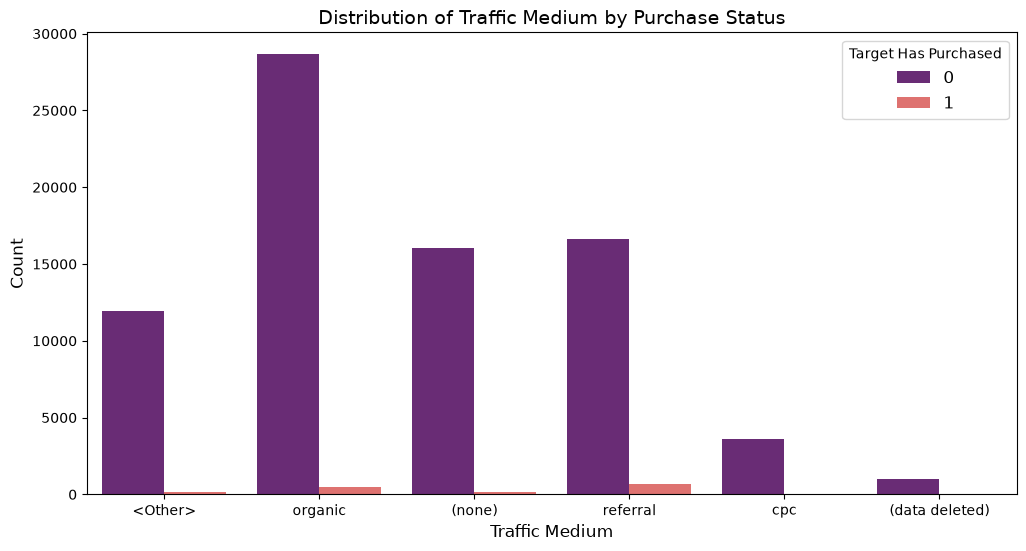

In [88]:
plt.figure(figsize=(12,6))
sns.countplot(data=e_commerce_df, x='traffic_medium', hue='target_has_purchased', palette='magma')
plt.title('Distribution of Traffic Medium by Purchase Status', fontsize = 14)
plt.xlabel('Traffic Medium', fontsize = 12)
plt.ylabel('Count', fontsize = 12)
plt.legend(title='Target Has Purchased', fontsize = 12)

### Analysis of Traffic Medium
While organic traffic brings the highest absolute volume of visitors to the website, analysis shows that the referral channel achieves the highest conversion rate (over 4%). This indicates that external recommendations or partner links bring more qualified, purchase-ready users, while organic traffic requires optimization to improve its conversion efficiency.

In [46]:
# Calculating average product views grouped by purchase status
view_comparison = e_commerce_df.groupby('target_has_purchased')['count_view_item'].mean()
print(view_comparison)

target_has_purchased
0     1.532219
1    19.122715
Name: count_view_item, dtype: float64


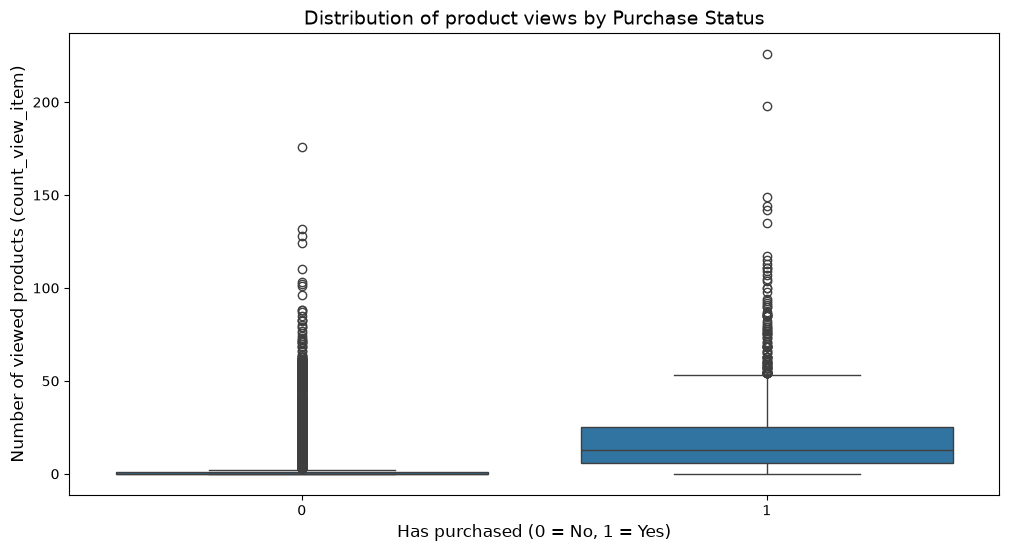

In [83]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=e_commerce_df, x='target_has_purchased', y='count_view_item')
plt.title('Distribution of product views by Purchase Status', fontsize = 14)
plt.xlabel('Has purchased (0 = No, 1 = Yes)', fontsize = 12)
plt.ylabel('Number of viewed products (count_view_item)', fontsize = 12)
plt.show()

### Analysis of Product Views 
The analysis shows a significant difference between users. Users who did not purchase (0) viewed an average of 1.53 products, while those who purchased (1) viewed an average of 19.12 products. This indicates that high engagement and deep catalog exploration are strong indicators of a future purchase.

In [50]:
cart_comparison = e_commerce_df.groupby('target_has_purchased')['count_add_to_cart'].mean()
print(cart_comparison)

target_has_purchased
0    0.056105
1    2.156658
Name: count_add_to_cart, dtype: float64


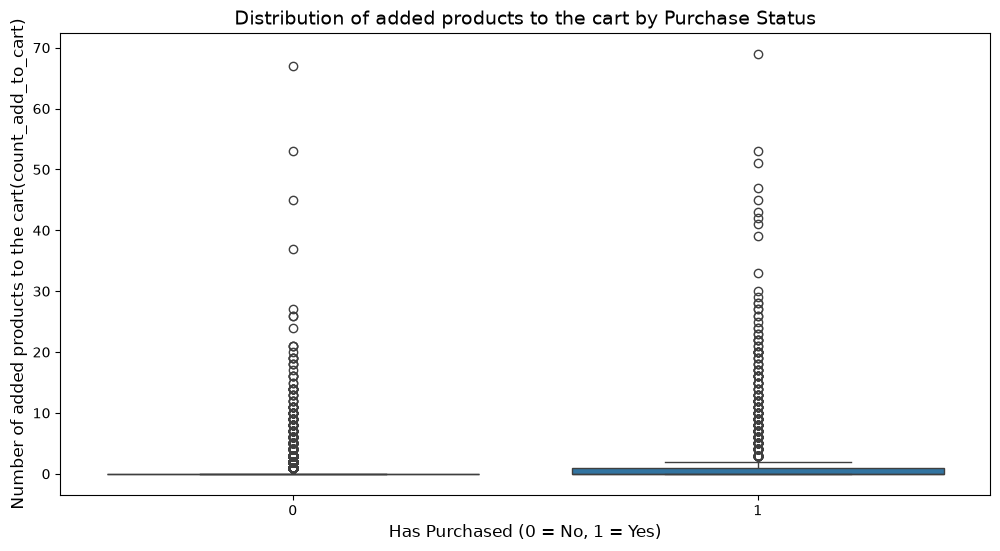

In [82]:
plt.figure(figsize=(12,6))
sns.boxplot(data=e_commerce_df, x='target_has_purchased', y='count_add_to_cart')
plt.title('Distribution of added products to the cart by Purchase Status', fontsize = 14)
plt.xlabel('Has Purchased (0 = No, 1 = Yes)', fontsize = 12)
plt.ylabel('Number of added products to the cart(count_add_to_cart)', fontsize = 12)
plt.show()


### Analysis Cart Additions 
The results reveal that adding items to the cart is a near-mandatory step for buying. Buyers added an average of 2.15 products to their cart, whereas non-buyers averaged close to zero (0.05). This confirms that a cart addition is a powerful predictor for our machine learning model.

In [54]:
checkout_comparison = e_commerce_df.groupby('target_has_purchased')['count_begin_checkout'].mean()
print(checkout_comparison)

target_has_purchased
0    0.060240
1    3.168407
Name: count_begin_checkout, dtype: float64


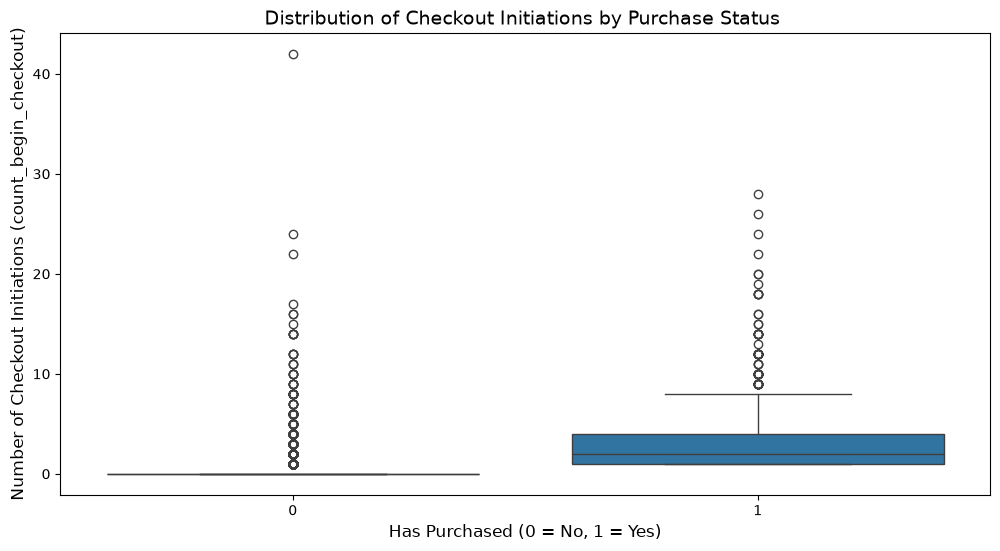

In [81]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=e_commerce_df, x='target_has_purchased', y='count_begin_checkout')
plt.title('Distribution of Checkout Initiations by Purchase Status ', fontsize = 14)
plt.xlabel('Has Purchased (0 = No, 1 = Yes)', fontsize = 12)
plt.ylabel('Number of Checkout Initiations (count_begin_checkout)', fontsize = 12)
plt.show()

### Analysis of Checkout Initiation
The results show that buyers initiated the checkout process an average of 3.16 times, while non-buyers averaged close to zero (0.06). This demonstrates that reaching the checkout stage is a critical milestone, confirming that progressing through the payment funnel is a strong indicator of a successful purchase.

In [ ]:
# calculating the conversion rate by device category
device_conversion = e_commerce_df.groupby('device_category')['target_has_purchased'].mean() * 100
print(device_conversion)

device_category
desktop    1.817547
mobile     2.100563
tablet     1.732812
Name: target_has_purchased, dtype: float64


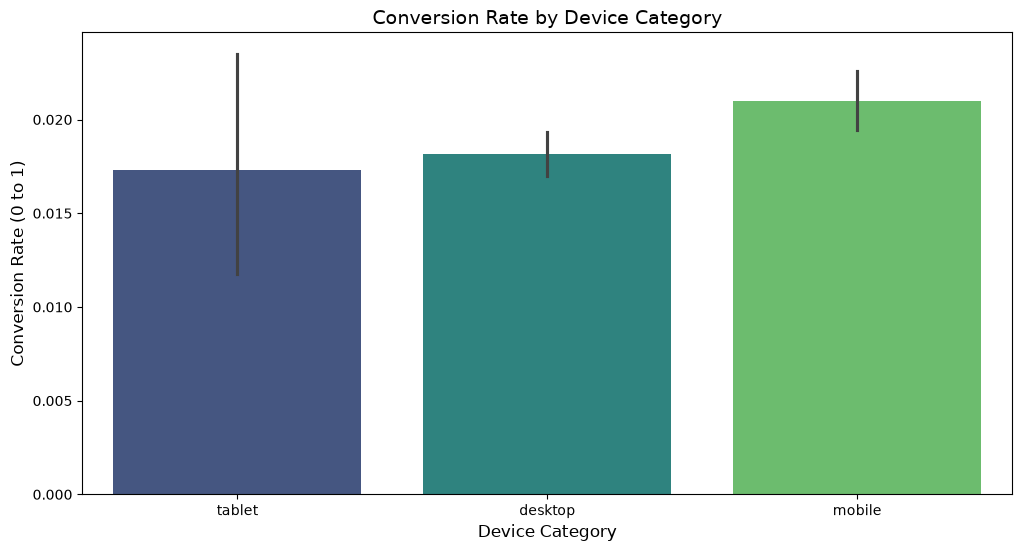

In [80]:
plt.figure(figsize=(12, 6))
sns.barplot(data=e_commerce_df, x='device_category', y='target_has_purchased', hue='device_category', legend=False,
            palette='viridis')
plt.title('Conversion Rate by Device Category', fontsize = 14)
plt.xlabel('Device Category', fontsize = 12)
plt.ylabel('Conversion Rate (0 to 1)', fontsize = 12)
plt.show()

### Analysis of Conversion Rate by Device Category

**Observation:**
The analysis of purchase rates across different devices reveals that **mobile** devices yield the highest conversion rate at **2.10%**, closely followed by **desktop** (1.82%) and **tablets** (1.73%). 

**Business Insight:**
While desktop users often generate higher total revenue due to larger cart sizes, mobile users show a slightly stronger tendency to finalize their purchases. This highlights the importance of maintaining a smooth and optimized mobile user experience (UX).

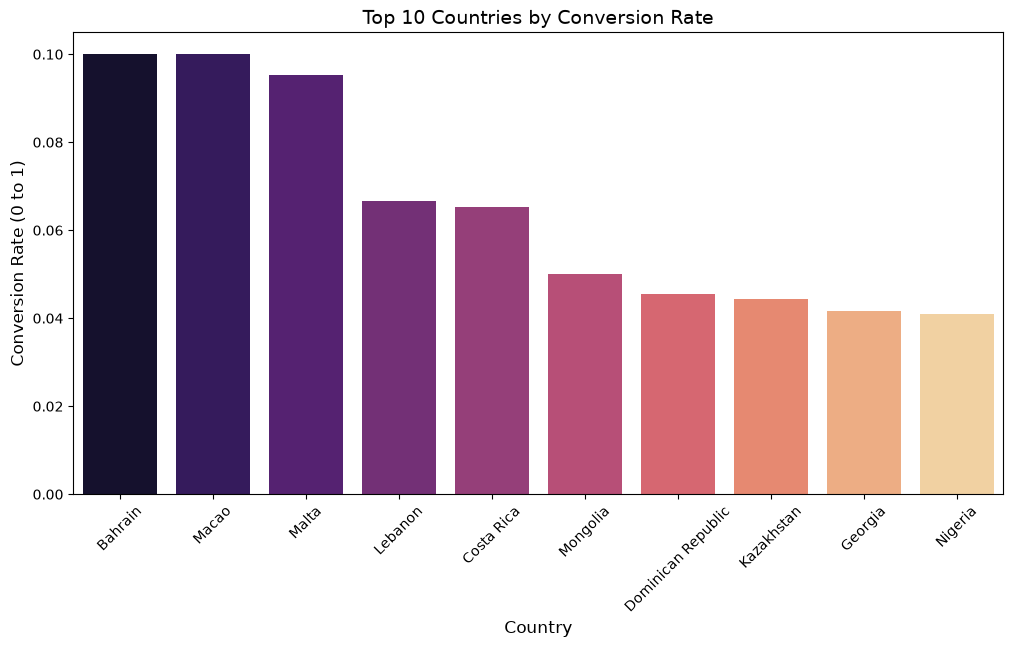

In [77]:
# Calculating the conversion rate by country, sorting in descending order, and selecting the top 10
top_countries = e_commerce_df.groupby('country')['target_has_purchased'].mean().reset_index()
top_countries = top_countries.sort_values(by='target_has_purchased', ascending=False).head(10)

# Creating the bar plot to visualize the top 10 countries by conversion rate
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_countries, 
    x='country', 
    y='target_has_purchased', 
    hue='country', 
    palette='magma', 
    legend=False
)

plt.title('Top 10 Countries by Conversion Rate', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Conversion Rate (0 to 1)', fontsize=12)

# Rotate country names to prevent overlapping on the X-axis
plt.xticks(rotation=45)
plt.show()

### Analysis of Conversion Rate by Country (Top 10)

**Observation:**
The analysis of the top-performing countries shows that **Bahrain** holds the highest conversion rate at approximately **10%**, closely followed by Macao and Malta. 

**Business Insight:**
Even though these countries might represent a smaller total volume of visitors compared to larger nations, they exhibit exceptional purchasing intent. This suggests targeted marketing or high-value customer segments present in these specific regions.